# ProtT5 Hyper-Ubiquitination Classifier: High vs Low/Other Ubiquitination Sites (Clean Pipeline)

This notebook builds a **clean, reproducible** classifier to predict whether a lysine site is **hyper-ubiquitinated** (c2_high) vs **low / non-differentially ubiquitinated** (c2_low + others), using **ProtT5-XL-UniRef50 (1024-dim)** per-residue embeddings of 15-residue context windows centred on each K site.

## Dataset
- **High** (`high_ubiq_sequences_with_pep_location_and_windows.csv`): 930 K-sites with high ubiquitination (c2_high group).
- **Low/Other** (`low_all_sequences_with_pep_location_and_windows.csv`): 15 730 K-sites with low or background ubiquitination (c2_low + others).

## What this notebook does
1. **Setup** — imports, paths, reproducibility seeds.
2. **Load data** — read both CSVs, inspect and validate.
3. **EDA** — class distribution, site composition, central residue (K) confirmation.
4. **ProtT5 embedding** — embed full protein sequences with `Rostlab/prot_t5_xl_uniref50` (1024-dim); cache to disk.
5. **Window extraction** — slice 15-residue context windows centred on each K-site.
6. **Train / test split** — stratified 80/20 split.
7. **Model training** — four architectures: Max-Pool MLP, Attention-Pool MLP, Center-Only MLP, Hybrid (Center + Attention).
8. **Evaluation** — ROC-AUC, PR-AUC, confusion matrices, classification reports.
9. **Visualisation** — ROC / PR curves, confusion matrices, PCA / t-SNE.
10. **Summary & report** — save all plots + HTML report to `results_ubiq_prott5/`.

> **Kernel required:** `esm2_env` (Python 3.11.8, transformers 4.x, sentencepiece, PyTorch 2.x, CUDA)  
> **Note:** ProtT5-XL has 3B parameters — `BATCH_SIZE=1` is used to avoid OOM.

## Cell 1 — Imports & Global Settings

In [1]:
import re
from pathlib import Path
import hashlib
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from transformers import T5Tokenizer, T5EncoderModel
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import transformers
print(f"PyTorch device  : {device}")
print(f"transformers    : {transformers.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")

/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/protT5_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/protT5_env/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


PyTorch device  : cuda
transformers    : 4.57.6
NumPy version   : 2.0.2
Pandas version  : 2.3.3


## Cell 2 — Paths & Results Directory

In [2]:
# Notebook lives in:  .../Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/
# Data files live in: .../Hyper_ubiquitination/Hyperacetylation_windows/

PROJECT_DIR = Path.cwd()                               # Claude_Agent_Hyper_Ubiquitination/
DATA_DIR    = PROJECT_DIR.parent / "Hyperacetylation_windows"
RESULTS_DIR = PROJECT_DIR / "results_ubiq_prott5"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

HIGH_FILE   = DATA_DIR / "high_ubiq_sequences_with_pep_location_and_windows.csv"
LOW_FILE    = DATA_DIR / "low_all_sequences_with_pep_location_and_windows.csv"
EMBED_CACHE = PROJECT_DIR / "prott5_ubiq_window_embeddings.npz"

print(f"Project dir  : {PROJECT_DIR}")
print(f"Data dir     : {DATA_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"High file    : {HIGH_FILE.exists()} — {HIGH_FILE}")
print(f"Low file     : {LOW_FILE.exists()} — {LOW_FILE}")
print(f"Embed cache  : {EMBED_CACHE.exists()} — {EMBED_CACHE}")

Project dir  : /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination
Data dir     : /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Hyperacetylation_windows
Results dir  : /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5
High file    : True — /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Hyperacetylation_windows/high_ubiq_sequences_with_pep_location_and_windows.csv
Low file     : True — /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Hyperacetylation_windows/low_all_sequences_with_pep_location_and_windows.csv
Embed cache  : False — /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/prott5_ubiq_window_embeddings.npz


## Cell 3 — Load & Validate Data

In [3]:
high_df = pd.read_csv(HIGH_FILE)
low_df  = pd.read_csv(LOW_FILE)

print(f"High ubiq shape : {high_df.shape}")
print(f"Low/other shape : {low_df.shape}")
print(f"\nHigh groups : {high_df['group'].value_counts().to_dict()}")
print(f"Low  groups : {low_df['group'].value_counts().to_dict()}")

required = ["Sequence", "win15_start", "win15_end", "win15_seq",
            "protein_id", "gene_name", "site"]
for col in required:
    assert col in high_df.columns, f"Missing column in HIGH: {col}"
    assert col in low_df.columns,  f"Missing column in LOW: {col}"
print("All required columns present.")

# Drop rows without valid 15-mer windows
high_clean = high_df.dropna(subset=["win15_start", "win15_end", "win15_seq", "Sequence"]).copy()
low_clean  = low_df.dropna(subset=["win15_start", "win15_end", "win15_seq", "Sequence"]).copy()

# Enforce strict 15-mer window length
high_clean = high_clean[(high_clean["win15_end"] - high_clean["win15_start"] + 1) == 15]
low_clean  = low_clean[(low_clean["win15_end"]   - low_clean["win15_start"]  + 1) == 15]

print(f"\nAfter cleaning:")
print(f"  High ubiq (positive) : {len(high_clean)} sites")
print(f"  Low/other (negative) : {len(low_clean)} sites")
print(f"  Imbalance ratio      : 1 : {len(low_clean)/len(high_clean):.1f}")

High ubiq shape : (930, 212)
Low/other shape : (15730, 212)

High groups : {'c2_high': 930}
Low  groups : {'others': 15639, 'c2_low': 91}
All required columns present.

After cleaning:
  High ubiq (positive) : 875 sites
  Low/other (negative) : 14035 sites
  Imbalance ratio      : 1 : 16.0


In [4]:
SHOW_COLS = ["protein_id", "gene_name", "site", "SequenceWindow", "win15_seq", "group"]
print("=== High ubiquitination sites (top 5) ===")
display(high_clean[SHOW_COLS].head())
print("\n=== Low/other ubiquitination sites (top 5) ===")
display(low_clean[SHOW_COLS].head())

=== High ubiquitination sites (top 5) ===


,protein_id,gene_name,site,SequenceWindow,win15_seq,group
0,ENSP00000324842,AACS,K228,EKLQQVVkGLPDLKK,EKLQQVVKGLPDLKK,c2_high
1,ENSP00000324842,AACS,K640,KKVEVAVkQIIAGKA,KKVEVAVKQIIAGKA,c2_high
2,ENSP00000218104,ABCD1,K513,TGPNGCGkSSLFRII,TGPNGCGKSSLFRIL,c2_high
3,ENSP00000218104,ABCD1,K683,EGGWKFEkLDSAARL,EGGWKFEKLDSAARL,c2_high
4,ENSP00000296577,ABCE1,K158,ELQNYFTkILEDDLK,ELQNYFTKILEDDLK,c2_high



=== Low/other ubiquitination sites (top 5) ===


,protein_id,gene_name,site,SequenceWindow,win15_seq,group
0,ENSP00000495778,ABHD5,K36,PTSISHLkEAEEKMI,PTSISHLKEAEEKML,c2_low
1,ENSP00000400452,ALDOA,K322,GGKKENLkAAQEEYV,GGKKENLKAAQEEYV,c2_low
2,ENSP00000236850,APOA1,K64,YVSQFEGsALGkQLN,FEGSALGKQLNLKLL,c2_low
3,ENSP00000355340,APOBEC3C,K175,FKPWKGLkTNFRLIK,FKPWKGLKTNFRLLK,c2_low
4,ENSP00000227667,APOC3,K71,TDGFSSLkDYWSTVK,TDGFSSLKDYWSTVK,c2_low


## Cell 4 — Exploratory Data Analysis (EDA)

/tmp/ipykernel_1111868/2730722010.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="Class", y="Count",


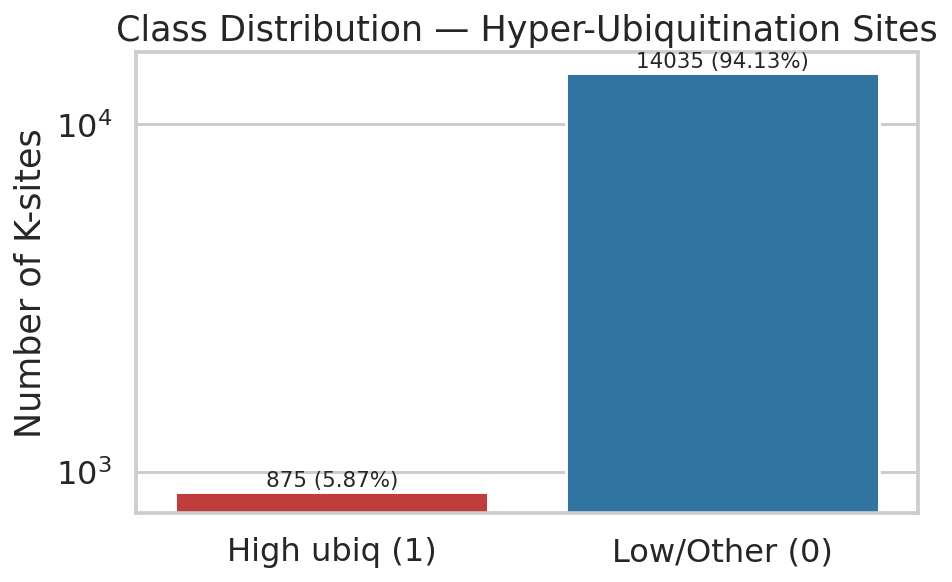

Saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/01_class_distribution.png


In [5]:
# ── Class distribution ──────────────────────────────────────────────────────
class_counts = pd.DataFrame({
    "Class":  ["High ubiq (1)", "Low/Other (0)"],
    "Count": [len(high_clean), len(low_clean)]
})
class_counts["Fraction"] = class_counts["Count"] / class_counts["Count"].sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=class_counts, x="Class", y="Count",
            palette=["#d62728", "#1f77b4"], ax=ax)
ax.set_title("Class Distribution — Hyper-Ubiquitination Sites")
ax.set_xlabel("")
ax.set_ylabel("Number of K-sites")
for i, row in class_counts.iterrows():
    ax.text(i, row["Count"] * 1.01,
            f"{row['Count']} ({row['Fraction']:.2%})",
            ha="center", va="bottom", fontsize=11)
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '01_class_distribution.png'}")

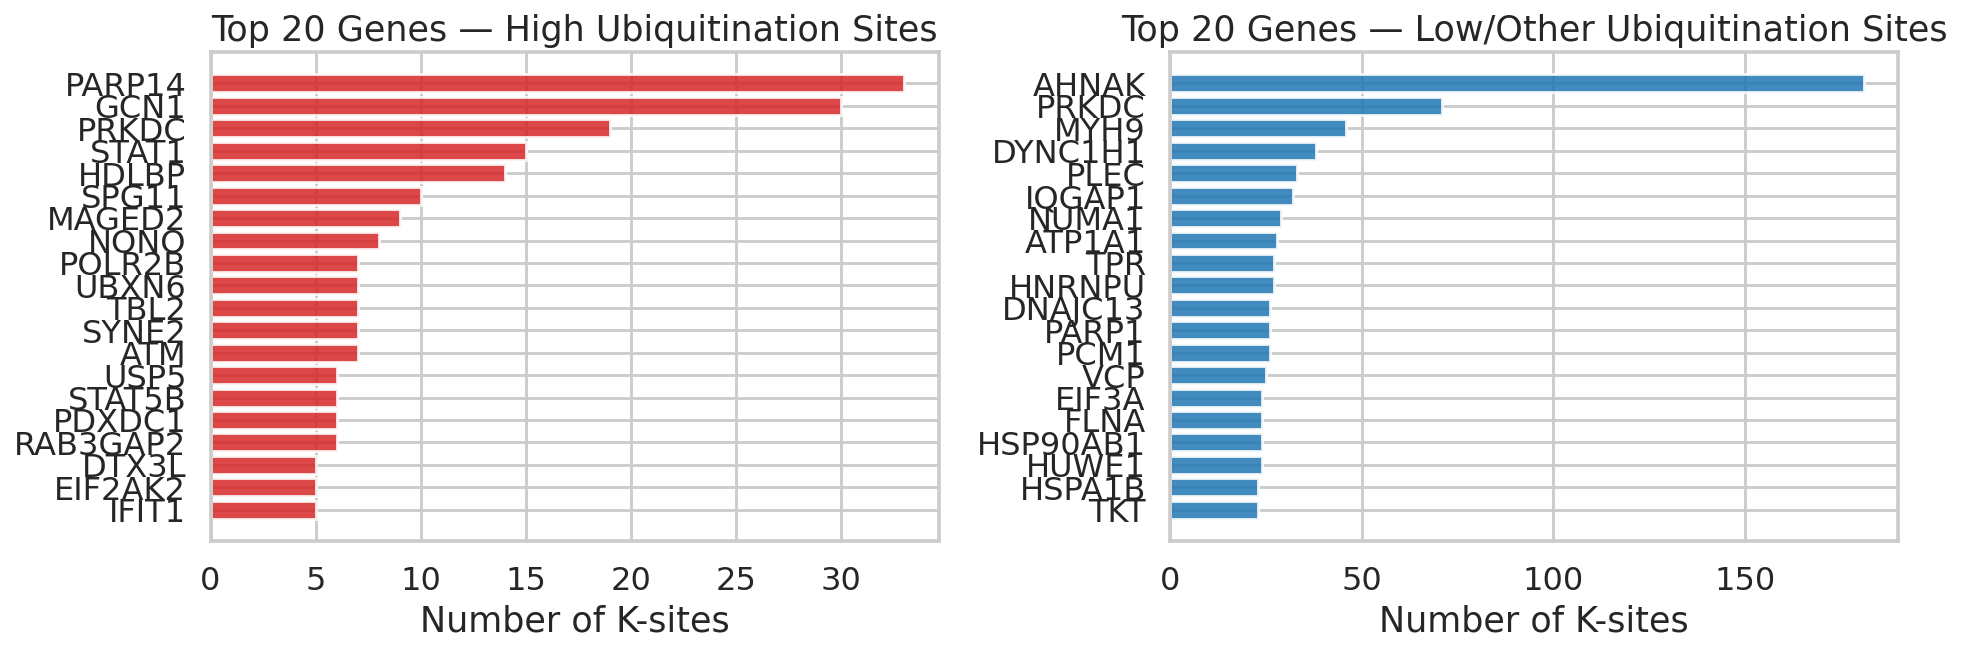

Saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/02_top_genes.png


In [6]:
# ── Top genes by site count ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_high = high_clean["gene_name"].value_counts().head(20)
top_low  = low_clean["gene_name"].value_counts().head(20)

axes[0].barh(top_high.index[::-1], top_high.values[::-1], color="#d62728", alpha=0.85)
axes[0].set_title("Top 20 Genes — High Ubiquitination Sites")
axes[0].set_xlabel("Number of K-sites")

axes[1].barh(top_low.index[::-1], top_low.values[::-1], color="#1f77b4", alpha=0.85)
axes[1].set_title("Top 20 Genes — Low/Other Ubiquitination Sites")
axes[1].set_xlabel("Number of K-sites")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_top_genes.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '02_top_genes.png'}")

Central residue in HIGH:
central_aa
K    875

Central residue in LOW:
central_aa
K    14035


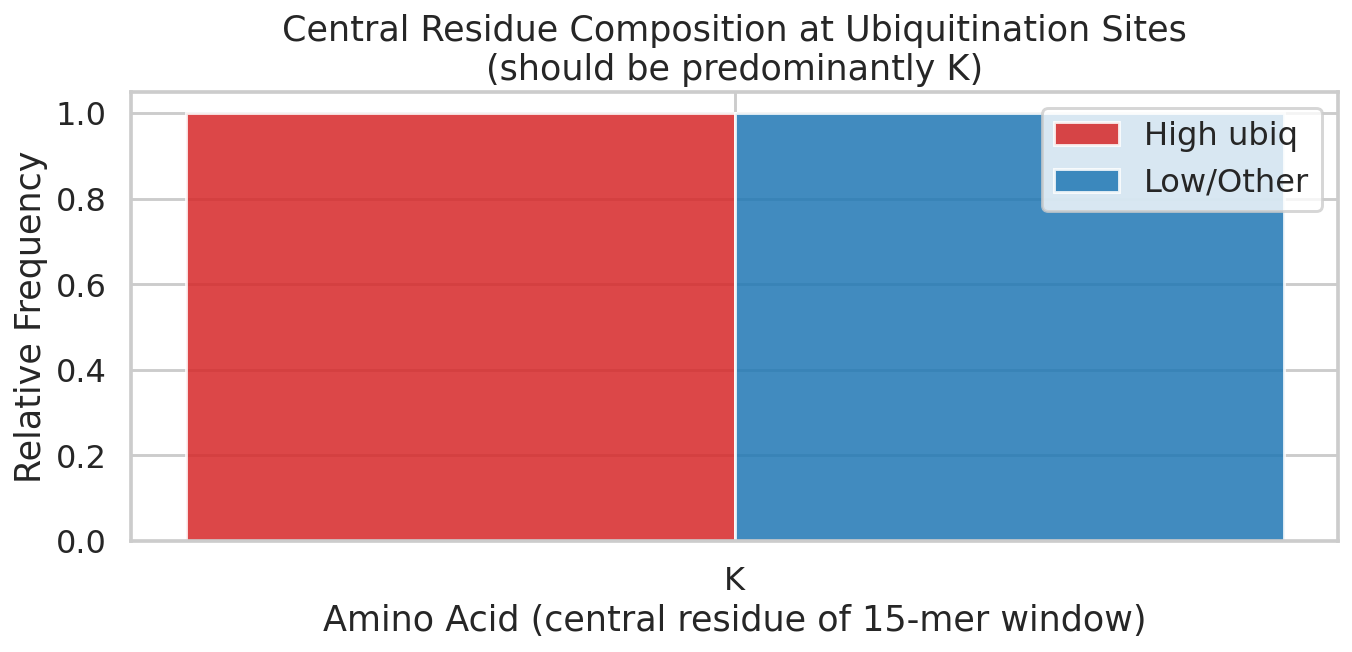

Saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/03_central_residue_composition.png


In [7]:
# ── Context window composition (positions around central K) ──────────────────
def central_residue(seq):
    if isinstance(seq, str) and len(seq) == 15:
        return seq[7].upper()
    return None

high_clean["central_aa"] = high_clean["win15_seq"].apply(central_residue)
low_clean["central_aa"]  = low_clean["win15_seq"].apply(central_residue)

print("Central residue in HIGH:")
print(high_clean["central_aa"].value_counts().to_string())
print("\nCentral residue in LOW:")
print(low_clean["central_aa"].value_counts().to_string())

aas = sorted(set(high_clean["central_aa"].dropna()) | set(low_clean["central_aa"].dropna()))
high_freq = high_clean["central_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)
low_freq  = low_clean["central_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)

x = np.arange(len(aas))
width = 0.4
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, high_freq.values, width, label="High ubiq",  color="#d62728", alpha=0.85)
ax.bar(x + width/2, low_freq.values,  width, label="Low/Other",  color="#1f77b4", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(aas)
ax.set_xlabel("Amino Acid (central residue of 15-mer window)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Central Residue Composition at Ubiquitination Sites\n(should be predominantly K)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_central_residue_composition.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '03_central_residue_composition.png'}")

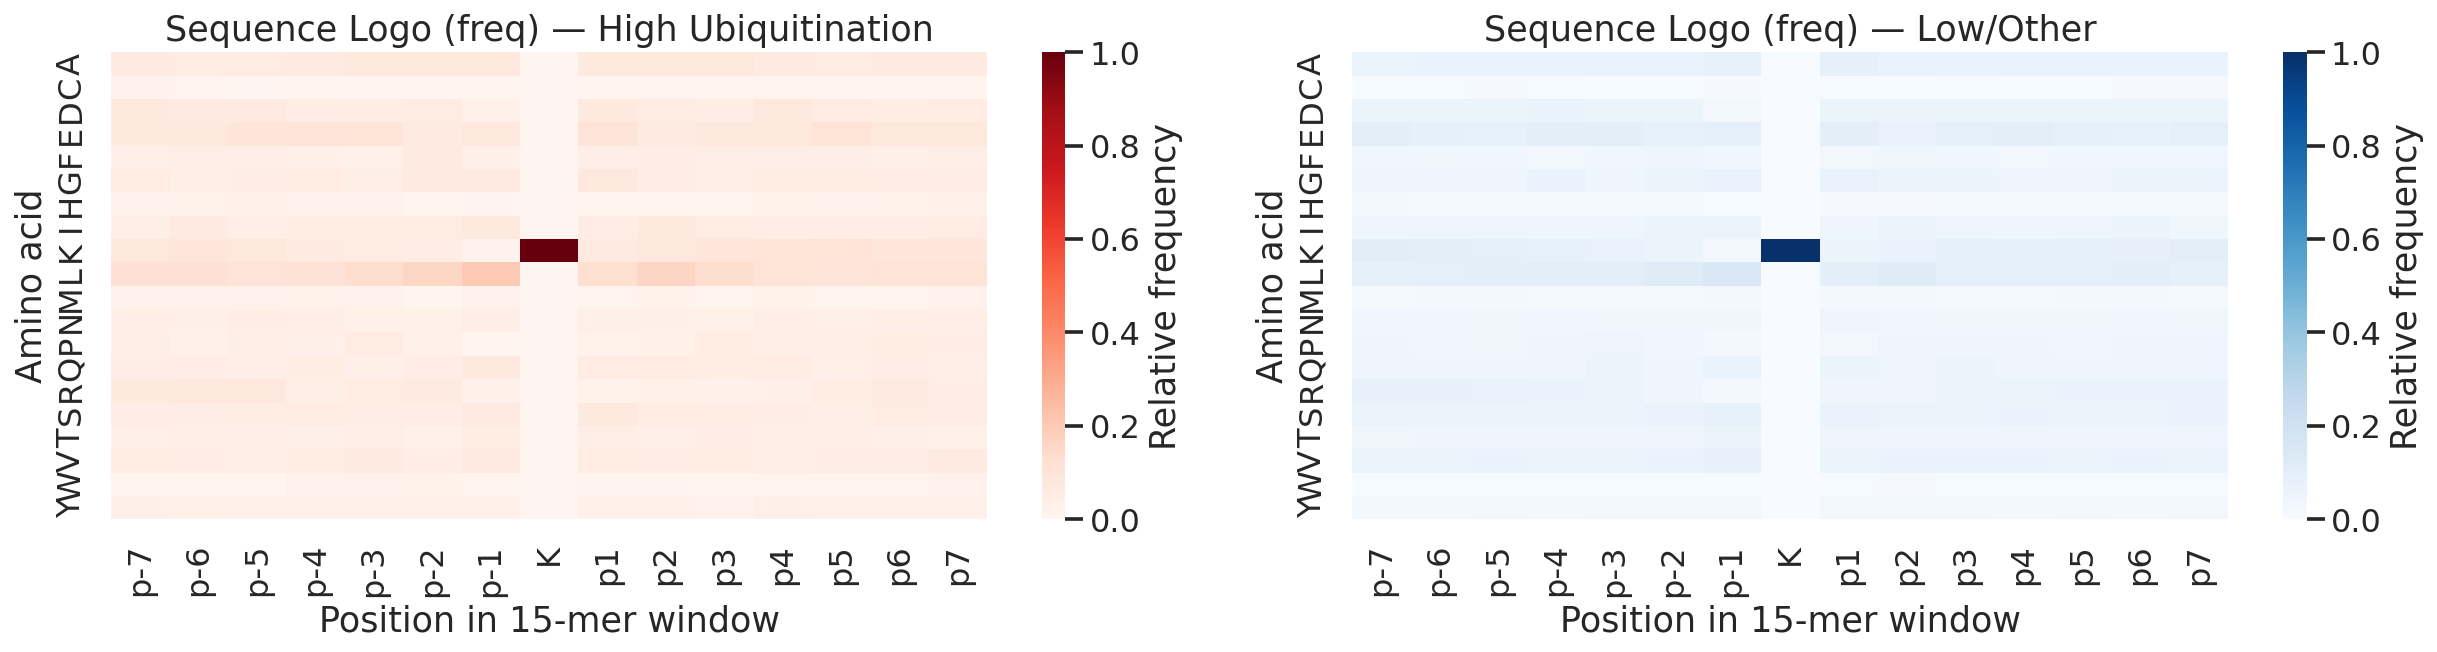

Saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/04_positional_aa_heatmap.png


In [8]:
# ── Flanking residue frequency (positions -7 to +7 around K) ─────────────────
def positional_freq(df, col="win15_seq"):
    """Return (15, 20) freq matrix over standard amino acids."""
    AAs = list("ACDEFGHIKLMNPQRSTVWY")
    counts = np.zeros((15, 20))
    total  = 0
    for seq in df[col].dropna():
        if len(seq) != 15:
            continue
        for pos, aa in enumerate(seq.upper()):
            if aa in AAs:
                counts[pos, AAs.index(aa)] += 1
        total += 1
    return counts / max(total, 1), AAs

freq_high, AAs = positional_freq(high_clean)
freq_low,  _   = positional_freq(low_clean)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
positions = [f"p{i-7}" if i != 7 else "K" for i in range(15)]

for ax, freq, title, cmap in [
    (axes[0], freq_high, "High Ubiquitination", "Reds"),
    (axes[1], freq_low,  "Low/Other",           "Blues")
]:
    sns.heatmap(freq.T, ax=ax, cmap=cmap, xticklabels=positions, yticklabels=AAs,
                cbar_kws={"label": "Relative frequency"})
    ax.set_title(f"Sequence Logo (freq) — {title}")
    ax.set_xlabel("Position in 15-mer window")
    ax.set_ylabel("Amino acid")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_positional_aa_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '04_positional_aa_heatmap.png'}")

## Cell 5 — ProtT5 Protein Embedding

We use **`Rostlab/prot_t5_xl_uniref50`** (1024-dim per-residue representations) via the HuggingFace `T5Tokenizer + T5EncoderModel` API.

**ProtT5 preprocessing rules:**
- Replace rare/ambiguous residues: `re.sub(r"[UZOB]", "X", seq.upper())`
- Space-separate all amino acids: `" ".join(list(seq))`
- Truncate to `PROTT5_MAX_LEN` *before* tokenisation

**No BOS offset needed** — T5 encoder does not prepend a BOS token.  
Slice: `hidden[j, :seq_len]` where `seq_len = len(seq_trunc)` (pre-truncation length).

**`BATCH_SIZE = 1`** — ProtT5-XL has 3 billion parameters.

In [9]:
PROTT5_MODEL_NAME = "Rostlab/prot_t5_xl_uniref50"
PROTT5_MAX_LEN    = 1024    # truncate proteins longer than this
PROTT5_BATCH_SIZE = 1       # 3B params — one sequence at a time


def sequence_to_id(seq: str) -> str:
    """Deterministic protein identifier (MD5 hash of sequence)."""
    return hashlib.md5(seq.encode()).hexdigest()


def preprocess_prott5(seq: str) -> str:
    """
    ProtT5 requires:
      1. Upper-case
      2. Replace U/Z/O/B → X
      3. Space-separate every amino acid
    """
    seq = re.sub(r"[UZOB]", "X", seq.upper())
    return " ".join(list(seq))


def load_prott5_model():
    print(f"Loading {PROTT5_MODEL_NAME} …")
    tokenizer = T5Tokenizer.from_pretrained(PROTT5_MODEL_NAME, do_lower_case=False)
    model = T5EncoderModel.from_pretrained(PROTT5_MODEL_NAME).to(device).eval()
    embed_dim = model.config.d_model
    print(f"ProtT5 model loaded | embed_dim={embed_dim}")
    return model, tokenizer, embed_dim


@torch.no_grad()
def embed_proteins_prott5(df: pd.DataFrame, model, tokenizer) -> dict:
    """
    Embed unique protein sequences with ProtT5-XL-UniRef50.
    Returns {protein_id: (seq_len, 1024) tensor on CPU}.

    T5 encoder does NOT add a BOS token → no offset correction.
    Preprocessing: space-separated AAs, rare residues → X.
    Sequences are truncated to PROTT5_MAX_LEN *before* tokenisation
    so seq_len = len(seq_trunc) aligns with hidden state positions.
    """
    emb_dict = {}
    unique_seqs = df["Sequence"].drop_duplicates().tolist()

    for raw_seq in tqdm(unique_seqs, desc="Embedding proteins (ProtT5)"):
        pid = sequence_to_id(raw_seq)

        # Truncate before preprocessing so seq_len is exact
        seq_trunc = raw_seq[:PROTT5_MAX_LEN]
        seq_len   = len(seq_trunc)
        seq_proc  = preprocess_prott5(seq_trunc)

        tokens = tokenizer(
            seq_proc,
            return_tensors="pt",
            padding=False,
            truncation=False,    # already truncated above
        ).to(device)

        out    = model(**tokens)
        hidden = out.last_hidden_state   # (1, seq_len+1, 1024)  — +1 for EOS token

        # Slice the amino-acid positions only (no EOS)
        emb_dict[pid] = hidden[0, :seq_len].cpu()   # (seq_len, 1024)

    return emb_dict


print("ProtT5 embedding functions defined.")

ProtT5 embedding functions defined.


In [10]:
# ── Load or compute ProtT5 protein embeddings ─────────────────────────────────
all_proteins = pd.concat(
    [high_clean[["Sequence"]], low_clean[["Sequence"]]]
).drop_duplicates()
print(f"Unique proteins to embed: {len(all_proteins)}")

if EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE} …")
    cache_data = np.load(EMBED_CACHE, allow_pickle=True)
    protein_embeddings = cache_data["embeddings"].item()
    print(f"Loaded {len(protein_embeddings)} embeddings from cache.")
else:
    print("Cache not found — running ProtT5 embedding (BATCH_SIZE=1, may take several hours) …")
    t0 = time.time()
    prott5_model, prott5_tokenizer, EMBED_DIM = load_prott5_model()
    protein_embeddings = embed_proteins_prott5(all_proteins, prott5_model, prott5_tokenizer)
    elapsed = time.time() - t0
    print(f"Embedding complete in {elapsed:.1f}s ({elapsed/3600:.2f}h) | {len(protein_embeddings)} proteins")
    np.savez(EMBED_CACHE, embeddings=protein_embeddings)
    print(f"Embeddings cached to {EMBED_CACHE}")
    del prott5_model, prott5_tokenizer
    if device.type == "cuda":
        torch.cuda.empty_cache()

EMBED_DIM = next(iter(protein_embeddings.values())).shape[1]
print(f"Embedding dim: {EMBED_DIM}")

Unique proteins to embed: 4411
Cache not found — running ProtT5 embedding (BATCH_SIZE=1, may take several hours) …
Loading Rostlab/prot_t5_xl_uniref50 …


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


ProtT5 model loaded | embed_dim=1024


Embedding proteins (ProtT5): 100%|██████████| 4411/4411 [08:47<00:00,  8.36it/s]


Embedding complete in 534.6s (0.15h) | 4411 proteins
Embeddings cached to /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/prott5_ubiq_window_embeddings.npz
Embedding dim: 1024


## Cell 6 — 15-Residue Window Extraction

In [11]:
def build_window_dataset(df: pd.DataFrame, label: int, protein_embeddings: dict):
    """
    Slice the 15-residue context window around each ubiquitination site.
    win15_start / win15_end are 0-based amino-acid positions.

    Returns:
        X    : (N, 15, EMBED_DIM) float32
        y    : (N,) int
        kept : original DataFrame indices that were kept
    """
    X, y, kept = [], [], []
    skipped_missing_emb = 0
    skipped_boundary    = 0

    for idx, row in df.iterrows():
        if pd.isna(row["win15_start"]) or pd.isna(row["win15_end"]):
            continue

        pid = sequence_to_id(row["Sequence"])
        if pid not in protein_embeddings:
            skipped_missing_emb += 1
            continue

        emb = protein_embeddings[pid]   # (L, 1024)
        s   = int(row["win15_start"])
        e   = int(row["win15_end"])

        if e - s + 1 != 15:
            continue

        if e >= emb.shape[0]:
            skipped_boundary += 1
            continue

        X.append(emb[s:e + 1].numpy())   # (15, 1024)
        y.append(label)
        kept.append(idx)

    print(f"[label={label}] Extracted {len(X)} windows "
          f"| skipped: {skipped_missing_emb} (no emb), {skipped_boundary} (boundary)")
    return np.stack(X), np.array(y), kept


X_pos, y_pos, idx_pos = build_window_dataset(high_clean, 1, protein_embeddings)
X_neg, y_neg, idx_neg = build_window_dataset(low_clean,  0, protein_embeddings)

X = np.concatenate([X_pos, X_neg], axis=0).astype(np.float32)  # (N, 15, 1024)
y = np.concatenate([y_pos, y_neg], axis=0)                     # (N,)

print(f"\nCombined dataset : X={X.shape}, y={y.shape}")
print(f"Class balance    : {(y==1).sum()} positive / {(y==0).sum()} negative")
print(f"Imbalance ratio  : 1 : {(y==0).sum()/(y==1).sum():.1f}")

[label=1] Extracted 768 windows | skipped: 0 (no emb), 107 (boundary)
[label=0] Extracted 12943 windows | skipped: 0 (no emb), 1092 (boundary)

Combined dataset : X=(13711, 15, 1024), y=(13711,)
Class balance    : 768 positive / 12943 negative
Imbalance ratio  : 1 : 16.9


## Cell 7 — Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Train set:")
print(f"  X_train : {X_train.shape}")
print(f"  Positive: {(y_train==1).sum()}  Negative: {(y_train==0).sum()}")
print(f"  Positive fraction: {(y_train==1).mean():.4f}")
print()
print("Test set:")
print(f"  X_test  : {X_test.shape}")
print(f"  Positive: {(y_test==1).sum()}  Negative: {(y_test==0).sum()}")
print(f"  Positive fraction: {(y_test==1).mean():.4f}")
print(f"  PR-AUC random baseline ≈ {(y_test==1).mean():.4f}")

Train set:
  X_train : (10968, 15, 1024)
  Positive: 614  Negative: 10354
  Positive fraction: 0.0560

Test set:
  X_test  : (2743, 15, 1024)
  Positive: 154  Negative: 2589
  Positive fraction: 0.0561
  PR-AUC random baseline ≈ 0.0561


## Cell 8 — Model Definitions

Four architectures operating on (B, 15, 1024) window tensors:

| Model | Description |
|---|---|
| **MaxPool MLP** | Max-pools 15 residues → 1024-dim → MLP |
| **AttentionPool MLP** | Learned attention weights over 15 residues → MLP |
| **CenterOnly MLP** | Uses only the K-site residue embedding (index 7) → MLP |
| **Hybrid** | Concatenates center residue + attention-pooled context → MLP |

In [13]:
class MaxPool(nn.Module):
    def forward(self, x):
        return x.max(dim=1).values


class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        scores  = self.attn(x).squeeze(-1)
        weights = F.softmax(scores, dim=1)
        return (x * weights.unsqueeze(-1)).sum(dim=1)


class UbiqMLP(nn.Module):
    """Generic MLP with pluggable pooling."""
    def __init__(self, pool: nn.Module, dim: int):
        super().__init__()
        self.pool = pool
        self.mlp = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.mlp(self.pool(x)).squeeze(-1)


class CenterOnlyMLP(nn.Module):
    """Uses only the K-site residue (index 7) of the 15-mer."""
    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x[:, 7, :]).squeeze(-1)


class HybridMLP(nn.Module):
    """K-site residue + attention-pooled context."""
    def __init__(self, dim: int):
        super().__init__()
        self.attn_pool = AttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128),     nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        center  = x[:, 7, :]
        context = self.attn_pool(x)
        return self.classifier(torch.cat([center, context], dim=1)).squeeze(-1)


print("All model classes defined.")

All model classes defined.


## Cell 9 — Training Loop

In [14]:
def train_and_eval(
    model: nn.Module,
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_va: np.ndarray, y_va: np.ndarray,
    epochs: int = 20,
    lr: float = 1e-3,
    batch_size: int = 64,
) -> tuple:
    """Train with class-weighted BCEWithLogitsLoss. Returns (probs, roc_auc, pr_auc)."""
    model = model.to(device)

    # Heavy class imbalance — weight positive class
    pos_weight = torch.tensor(
        (y_tr == 0).sum() / max((y_tr == 1).sum(), 1), dtype=torch.float32
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=True,
    )

    val_X = torch.tensor(X_va, dtype=torch.float32).to(device)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(val_X)).cpu().numpy()

    return probs, roc_auc_score(y_va, probs), average_precision_score(y_va, probs)


print("Training helper defined.")

Training helper defined.


In [15]:
D = EMBED_DIM   # 1024 for ProtT5-XL

models_to_train = {
    "MaxPool MLP":     UbiqMLP(MaxPool(),       dim=D),
    "AttnPool MLP":    UbiqMLP(AttentionPool(D), dim=D),
    "CenterOnly MLP":  CenterOnlyMLP(dim=D),
    "Hybrid (C+Attn)": HybridMLP(dim=D),
}

results = {}

for name, model in models_to_train.items():
    print(f"Training: {name} …", end=" ", flush=True)
    t0 = time.time()
    probs, roc, pr = train_and_eval(
        model, X_train, y_train, X_test, y_test, epochs=20
    )
    elapsed = time.time() - t0
    results[name] = {"probs": probs, "roc_auc": roc, "pr_auc": pr}
    print(f"AUROC={roc:.4f}  AUPRC={pr:.4f}  [{elapsed:.1f}s]")

print("\nAll models trained.")

Training: MaxPool MLP … AUROC=0.7426  AUPRC=0.1750  [7.2s]
Training: AttnPool MLP … AUROC=0.7589  AUPRC=0.2431  [8.1s]
Training: CenterOnly MLP … AUROC=0.7495  AUPRC=0.1822  [7.5s]
Training: Hybrid (C+Attn) … AUROC=0.7724  AUPRC=0.2590  [8.4s]

All models trained.


## Cell 10 — ROC & Precision-Recall Curves

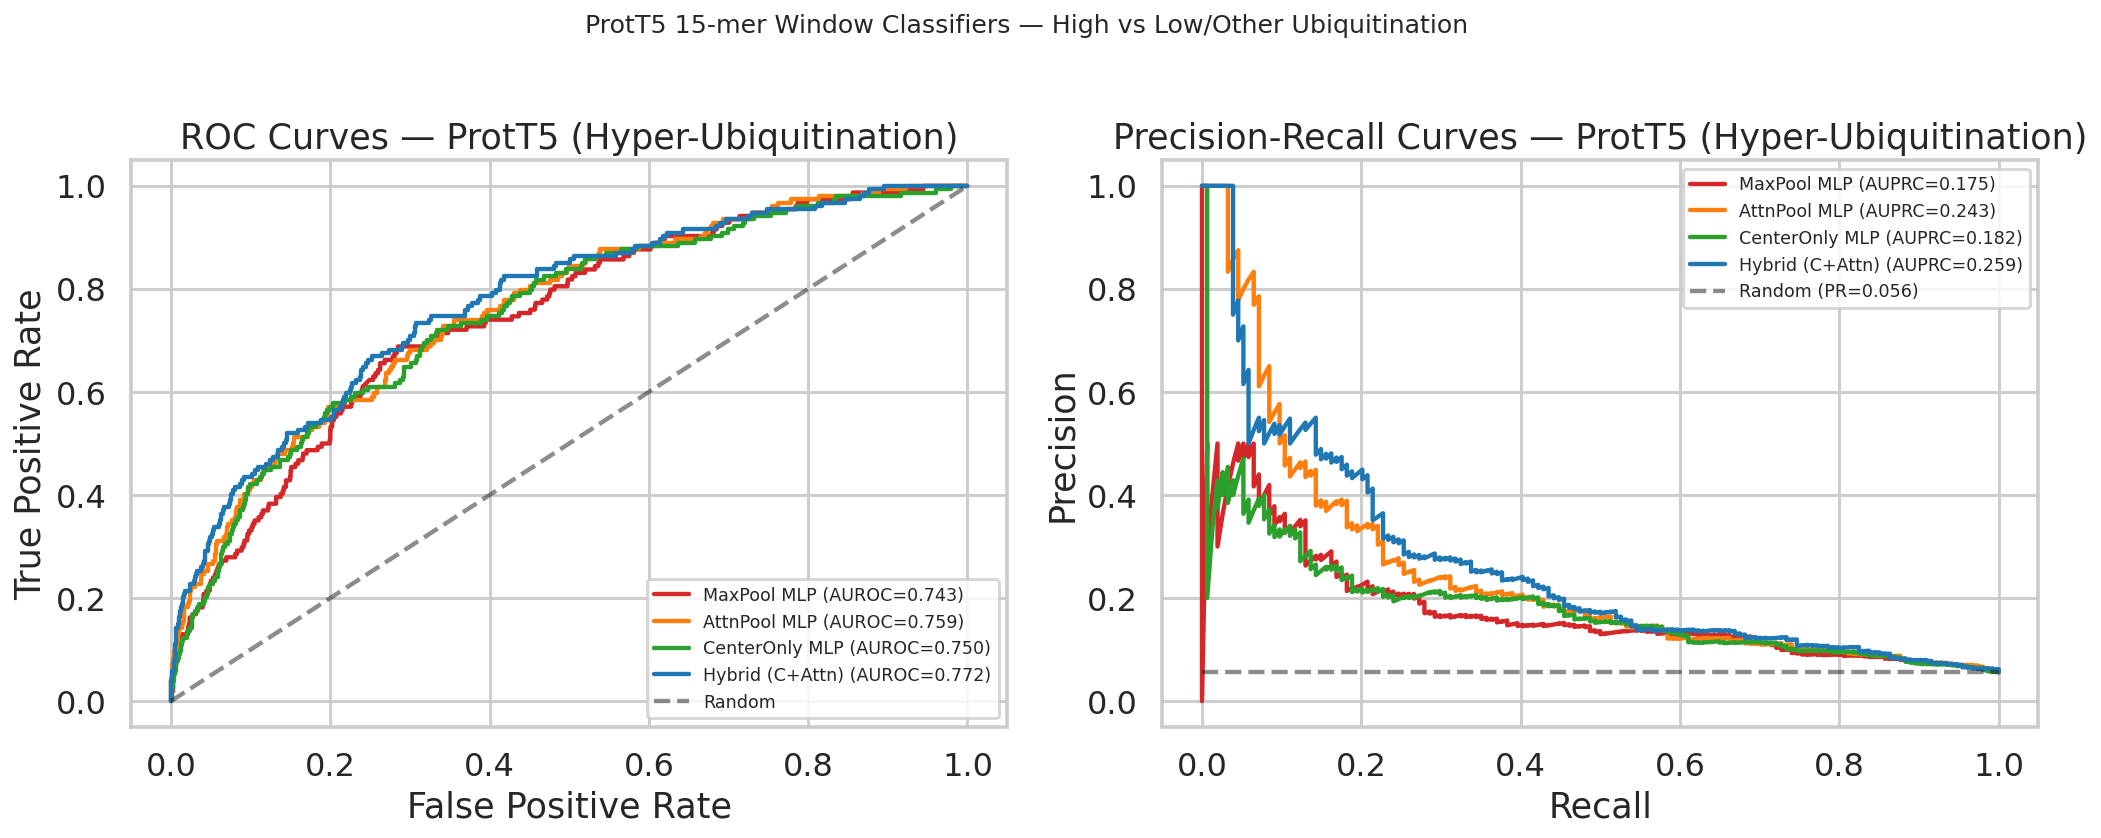

Saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/05_roc_pr_curves.png


In [16]:
PALETTE = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
baseline_pr = (y_test == 1).mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for (name, res), color in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUROC={res['roc_auc']:.3f})", color=color)

    prec, rec, _ = precision_recall_curve(y_test, res["probs"])
    axes[1].plot(rec, prec, label=f"{name} (AUPRC={res['pr_auc']:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — ProtT5 (Hyper-Ubiquitination)")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].hlines(baseline_pr, 0, 1, linestyles="--", colors="k", alpha=0.5,
               label=f"Random (PR={baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — ProtT5 (Hyper-Ubiquitination)")
axes[1].legend(loc="upper right", fontsize=9)

plt.suptitle("ProtT5 15-mer Window Classifiers — High vs Low/Other Ubiquitination",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '05_roc_pr_curves.png'}")

## Cell 11 — Detailed Metrics & Confusion Matrices

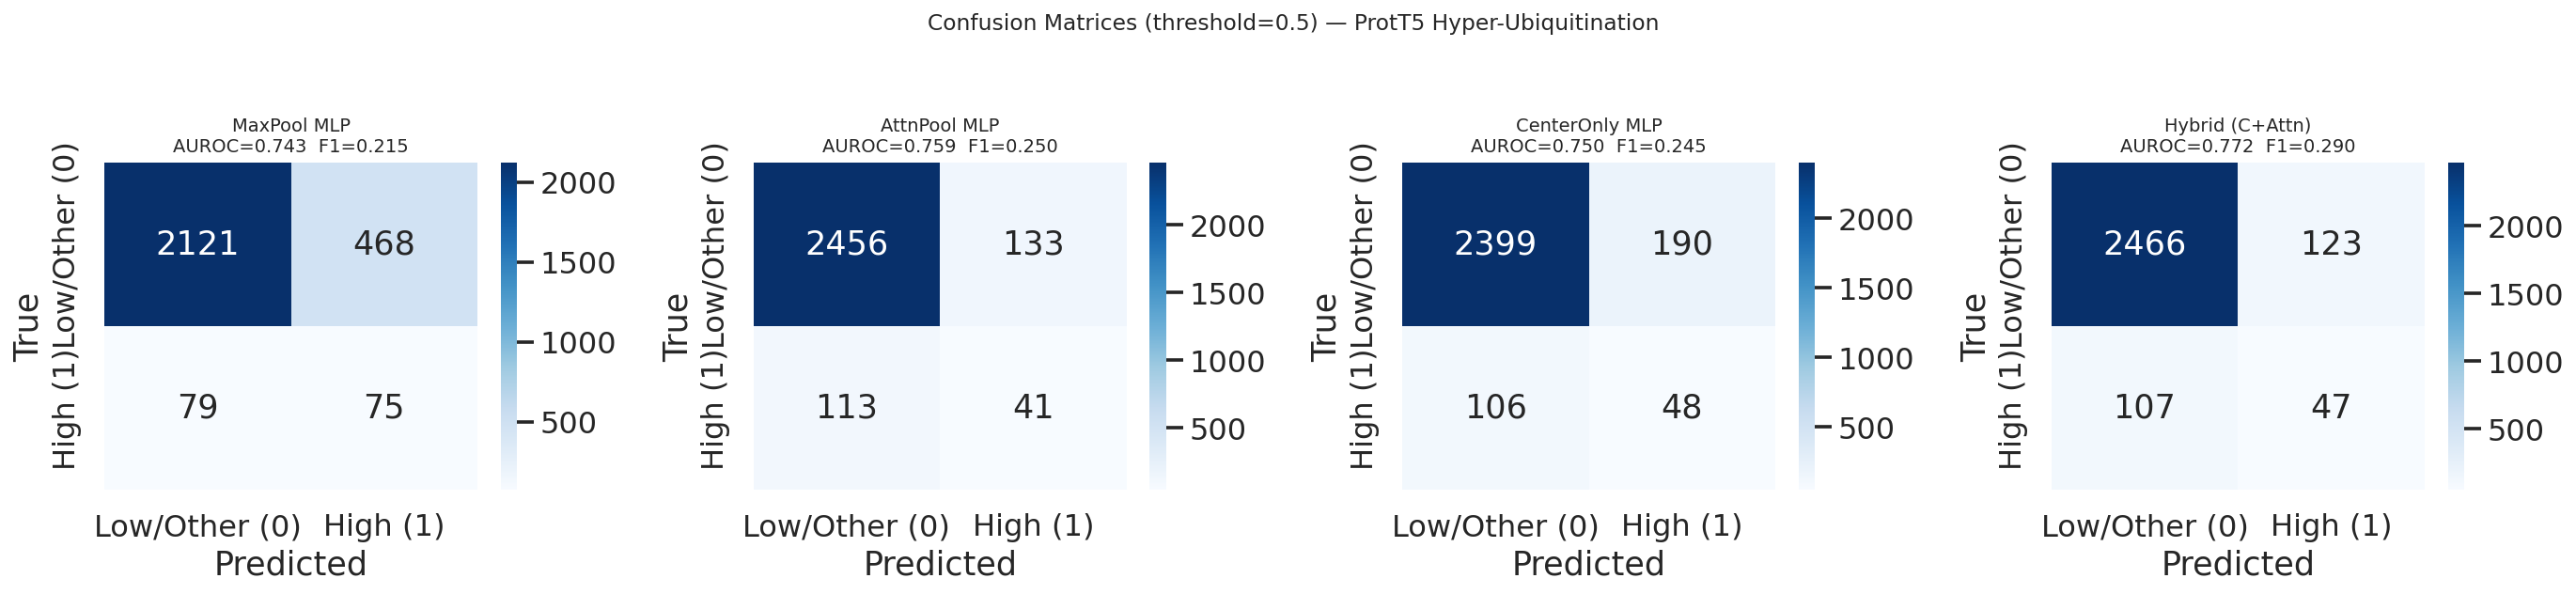

Saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/06_confusion_matrices.png


In [17]:
THRESHOLD = 0.5
metrics_rows = []

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    preds = (res["probs"] >= THRESHOLD).astype(int)
    prec  = precision_score(y_test, preds, zero_division=0)
    rec   = recall_score(y_test, preds, zero_division=0)
    f1    = f1_score(y_test, preds, zero_division=0)

    metrics_rows.append({
        "Model":     name,
        "AUROC":     round(res["roc_auc"], 4),
        "AUPRC":     round(res["pr_auc"], 4),
        "Precision": round(prec, 4),
        "Recall":    round(rec, 4),
        "F1":        round(f1, 4),
    })

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Low/Other (0)", "High (1)"],
        yticklabels=["Low/Other (0)", "High (1)"],
    )
    ax.set_title(f"{name}\nAUROC={res['roc_auc']:.3f}  F1={f1:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices (threshold=0.5) — ProtT5 Hyper-Ubiquitination", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "06_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '06_confusion_matrices.png'}")

In [18]:
metrics_df = pd.DataFrame(metrics_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
print("=== Model Performance Summary ===")
display(metrics_df)

metrics_df.to_csv(RESULTS_DIR / "07_model_metrics_summary.csv", index=False)
print(f"\nSaved: {RESULTS_DIR / '07_model_metrics_summary.csv'}")

=== Model Performance Summary ===


,Model,AUROC,AUPRC,Precision,Recall,F1
0,Hybrid (C+Attn),0.7724,0.2590,0.2765,0.3052,0.2901
1,AttnPool MLP,0.7589,0.2431,0.2356,0.2662,0.2500
2,CenterOnly MLP,0.7495,0.1822,0.2017,0.3117,0.2449
3,MaxPool MLP,0.7426,0.1750,0.1381,0.4870,0.2152



Saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/07_model_metrics_summary.csv


## Cell 12 — Embedding Visualisation (PCA + t-SNE)

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Subsample for t-SNE speed (keep all positives, random subset of negatives)
rng = np.random.default_rng(SEED)
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
neg_sub = rng.choice(neg_idx, size=min(len(pos_idx) * 5, len(neg_idx)), replace=False)
vis_idx = np.concatenate([pos_idx, neg_sub])
X_vis = X[vis_idx].mean(axis=1)   # (N_vis, 1024) mean-pooled
y_vis = y[vis_idx]
print(f"Visualisation subset: {len(vis_idx)} samples ({len(pos_idx)} pos + {len(neg_sub)} neg)")

pca = PCA(n_components=50, random_state=SEED)
X_pca50 = pca.fit_transform(X_vis)
print(f"PCA 50-component variance explained: {pca.explained_variance_ratio_.sum():.2%}")
X_pca2 = X_pca50[:, :2]

print("Running t-SNE …")
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print("t-SNE done.")

Visualisation subset: 4608 samples (768 pos + 3840 neg)
PCA 50-component variance explained: 58.76%
Running t-SNE …
t-SNE done.


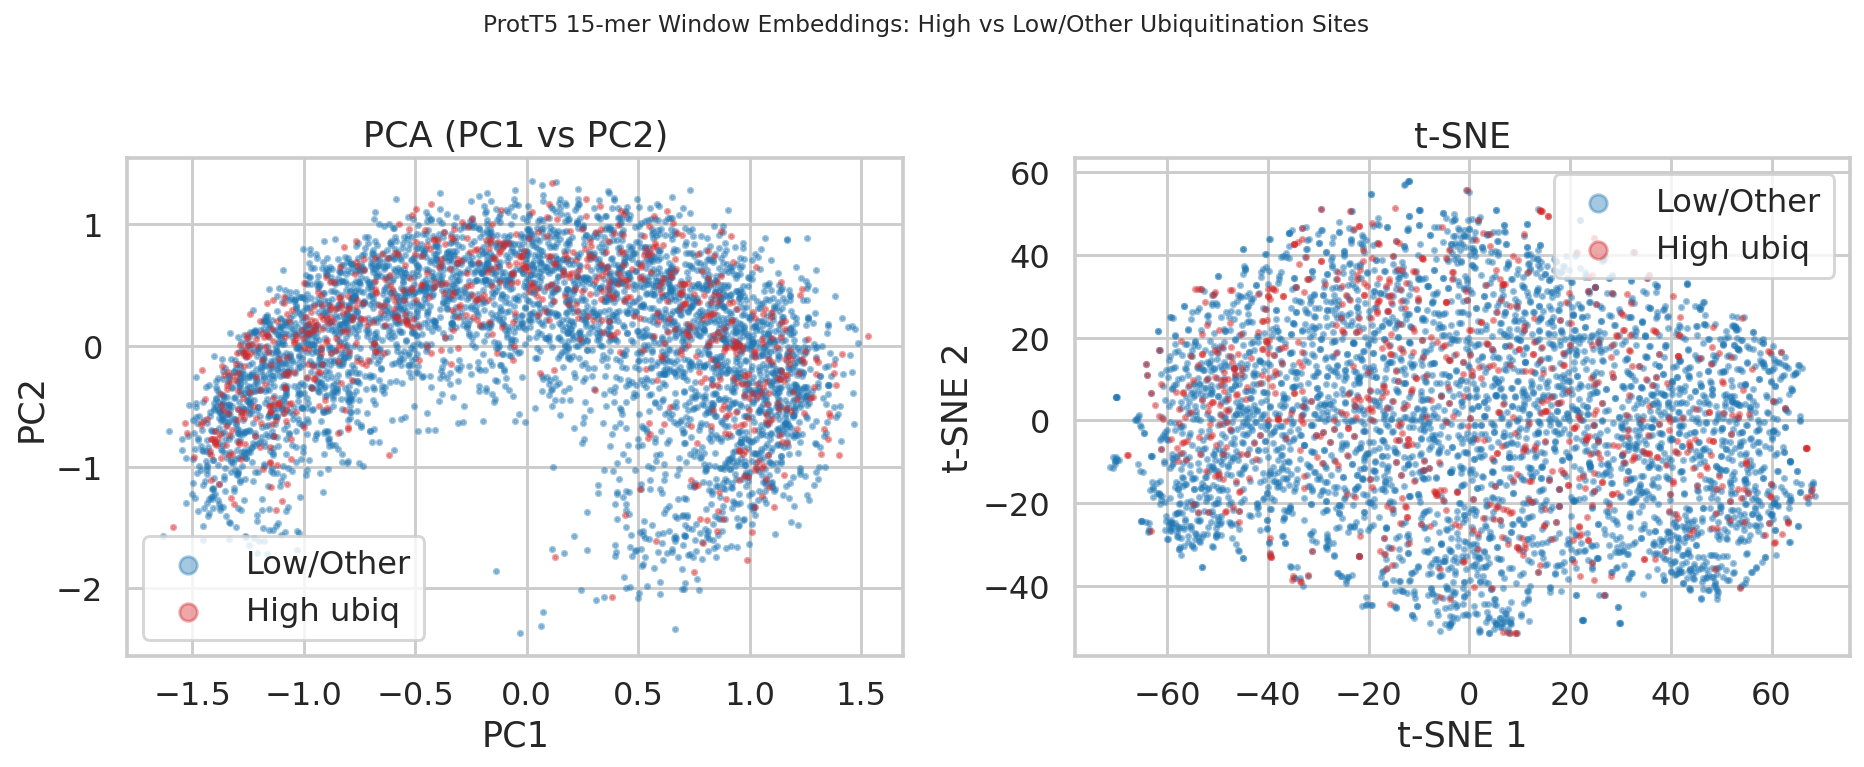

Saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/08_pca_tsne.png


In [20]:
label_colors = {1: "#d62728", 0: "#1f77b4"}
label_names  = {1: "High ubiq", 0: "Low/Other"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for label in [0, 1]:
    mask = y_vis == label
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    s=5, alpha=0.4, color=label_colors[label],
                    label=label_names[label], rasterized=True)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=5, alpha=0.4, color=label_colors[label],
                    label=label_names[label], rasterized=True)

axes[0].set_title("PCA (PC1 vs PC2)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=4)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(markerscale=4)

plt.suptitle("ProtT5 15-mer Window Embeddings: High vs Low/Other Ubiquitination Sites",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_pca_tsne.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '08_pca_tsne.png'}")

## Cell 13 — HTML Summary Report

In [21]:
import base64


def img_to_b64(path: Path) -> str:
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="max-width:100%;"/>'


plot_files   = sorted(RESULTS_DIR.glob("*.png"))
metrics_html = metrics_df.to_html(index=False, border=1,
                                   classes="metrics", justify="center")

html_parts = [
    """<!DOCTYPE html>
<html><head>
<meta charset='utf-8'/>
<title>ProtT5 Hyper-Ubiquitination — Analysis Report</title>
<style>
  body { font-family: Arial, sans-serif; max-width: 1100px; margin: auto; padding: 20px; }
  h1   { color: #145a32; }
  h2   { color: #2c3e50; border-bottom: 2px solid #ccc; padding-bottom: 4px; }
  table.metrics { border-collapse: collapse; width: 100%; }
  table.metrics th, table.metrics td { border: 1px solid #aaa; padding: 8px 14px; text-align: center; }
  table.metrics th { background-color: #145a32; color: white; }
  .plot-grid { display: flex; flex-wrap: wrap; gap: 16px; }
  .plot-grid figure { margin: 0; text-align: center; }
</style>
</head><body>
<h1>ProtT5 Hyper-Ubiquitination Classifier</h1>
<h2>Dataset: High vs Low/Other Ubiquitination K-Sites</h2>
<p><b>Positive (High ubiq):</b> 930 K-sites &nbsp;|&nbsp; <b>Negative (Low/Other):</b> 15 730 K-sites</p>
<p><b>Model:</b> ProtT5-XL-UniRef50 (1024-dim) 15-residue context window centred on each K-site</p>
<p><b>Preprocessing:</b> <code>re.sub(r"[UZOB]", "X", seq.upper())</code> → space-separated AAs → T5Tokenizer</p>
<p><b>No BOS offset:</b> <code>hidden[j, :seq_len]</code> where <code>seq_len = len(seq_trunc)</code></p>
<hr/>
<h2>Model Performance Summary</h2>
""",
    metrics_html,
    "<hr/>\n<h2>Plots</h2>\n<div class='plot-grid'>\n",
]

for p in plot_files:
    html_parts.append(f"<figure>{img_to_b64(p)}<figcaption>{p.name}</figcaption></figure>\n")

html_parts.append("</div></body></html>")

report_path = RESULTS_DIR / "report_hyper_ubiq_prott5.html"
report_path.write_text("".join(html_parts), encoding="utf-8")
print(f"HTML report saved: {report_path}")

HTML report saved: /home/saishyam/Protein_dynamics/Hyper_ubiquitination/Claude_Agent_Hyper_Ubiquitination/results_ubiq_prott5/report_hyper_ubiq_prott5.html


## Cell 14 — Final Summary

In [22]:
print("=" * 60)
print("FINAL RESULTS SUMMARY — ProtT5 Hyper-Ubiquitination")
print("=" * 60)
print(f"Dataset  : Hyper-ubiquitination K-sites")
print(f"Positive : High ubiq (c2_high)           ({(y==1).sum()} samples)")
print(f"Negative : Low/other ubiq (c2_low+other) ({(y==0).sum()} samples)")
print(f"Imbalance: 1 : {(y==0).sum()/(y==1).sum():.1f}")
print(f"Embedder : ProtT5-XL-UniRef50, 1024 dim, 15-residue window around K-site")
print(f"Split    : 80% train / 20% test, stratified")
print()

random_auroc = 0.5
random_prauc = (y_test == 1).mean()
print("Random baselines (test set):")
print(f"  AUROC  (random) = {random_auroc:.4f}")
print(f"  PR-AUC (random) = {random_prauc:.4f}  "
      f"[= positive fraction = {(y_test==1).sum()}/{len(y_test)}]")
print()

print("Model Results vs Random Baseline:")
print(f"{'Model':<20} {'AUROC':>7} {'vs_rand':>9} {'AUPRC':>7} {'vs_rand':>9} {'F1':>7}")
print("-" * 65)
for _, row in metrics_df.iterrows():
    auroc_gain = row["AUROC"] - random_auroc
    prauc_gain = row["AUPRC"] - random_prauc
    print(f"{row['Model']:<20} {row['AUROC']:>7.4f} {auroc_gain:>+9.4f} "
          f"{row['AUPRC']:>7.4f} {prauc_gain:>+9.4f} {row['F1']:>7.4f}")
print()

best = metrics_df.iloc[0]
print(f"Best model : {best['Model']}")
print(f"  AUROC  = {best['AUROC']:.4f}  (random = {random_auroc:.4f}, "
      f"gain = {best['AUROC'] - random_auroc:+.4f})")
print(f"  PR-AUC = {best['AUPRC']:.4f}  (random = {random_prauc:.4f}, "
      f"gain = {best['AUPRC'] - random_prauc:+.4f})")
print(f"  F1     = {best['F1']:.4f}")
print()
print("All outputs saved to:", RESULTS_DIR.resolve())
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}")

FINAL RESULTS SUMMARY — ProtT5 Hyper-Ubiquitination
Dataset  : Hyper-ubiquitination K-sites
Positive : High ubiq (c2_high)           (768 samples)
Negative : Low/other ubiq (c2_low+other) (12943 samples)
Imbalance: 1 : 16.9
Embedder : ProtT5-XL-UniRef50, 1024 dim, 15-residue window around K-site
Split    : 80% train / 20% test, stratified

Random baselines (test set):
  AUROC  (random) = 0.5000
  PR-AUC (random) = 0.0561  [= positive fraction = 154/2743]

Model Results vs Random Baseline:
Model                  AUROC   vs_rand   AUPRC   vs_rand      F1
-----------------------------------------------------------------
Hybrid (C+Attn)       0.7724   +0.2724  0.2590   +0.2029  0.2901
AttnPool MLP          0.7589   +0.2589  0.2431   +0.1870  0.2500
CenterOnly MLP        0.7495   +0.2495  0.1822   +0.1261  0.2449
MaxPool MLP           0.7426   +0.2426  0.1750   +0.1189  0.2152

Best model : Hybrid (C+Attn)
  AUROC  = 0.7724  (random = 0.5000, gain = +0.2724)
  PR-AUC = 0.2590  (random = 0.0